In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


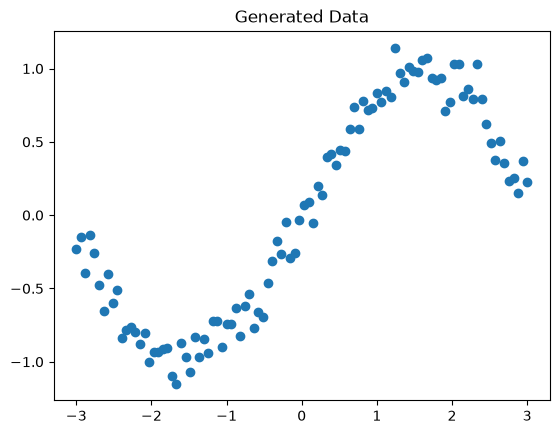

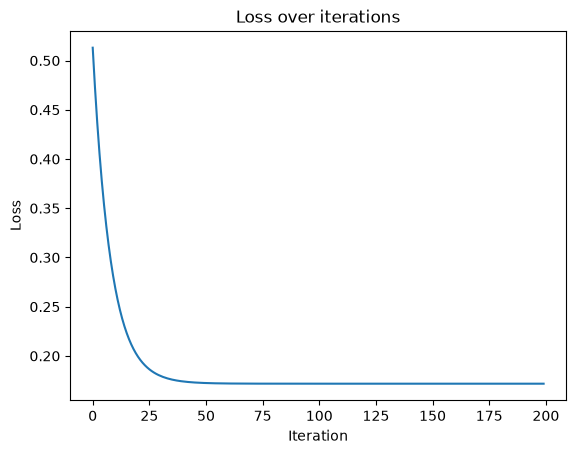

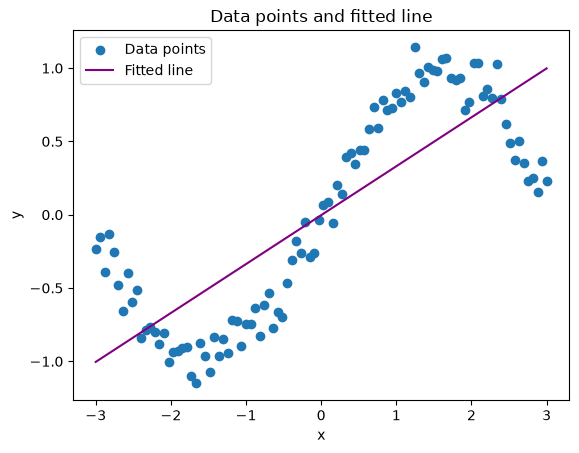

In [12]:
# Section 1: Inside a Neural Network

# Generatex values
x = np.linspace(-3, 3, 100)

# Generate random noise
noise = np.random.normal(0, 0.1, 100)

# Generate y values + noise
y = np.sin(x) + noise

# plotting
plt.scatter(x, y, label="Data points")
plt.title("Generated Data")
plt.show()

# Initializing the weight and bias
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# Implementing one gradient descent step
lr = 0.01
losses = []


for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)  # Mean squared error
    losses.append(loss)

    # Calculating gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Updating weights and bias
    w = w - lr * dw
    b = b - lr * db

# Plotting the loss curve over 200 steps
plt.plot(losses)
plt.title("Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# Plotting the data with the fitted line top
y_hat = w * x + b
plt.scatter(x, y, label="Data points")
plt.plot(x, y_hat, color="purple", label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data points and fitted line")
plt.legend()
plt.show()


Student Reasoning
1.
2.

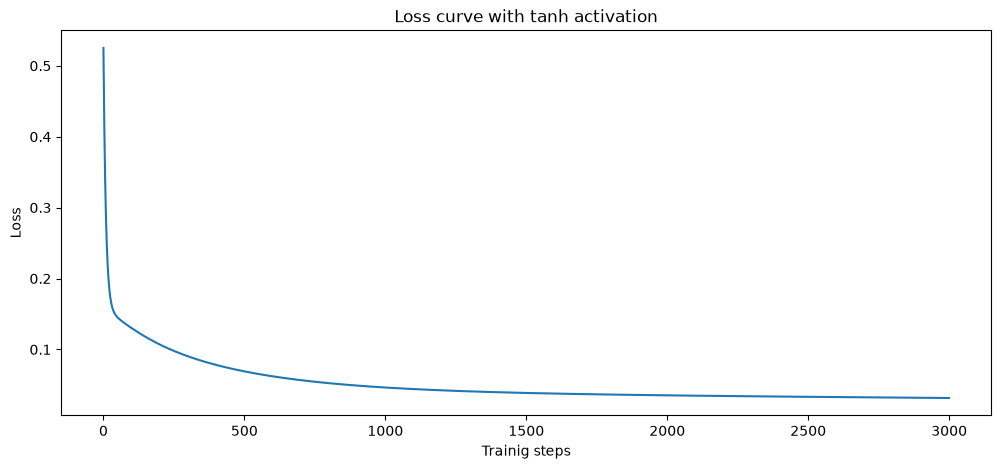

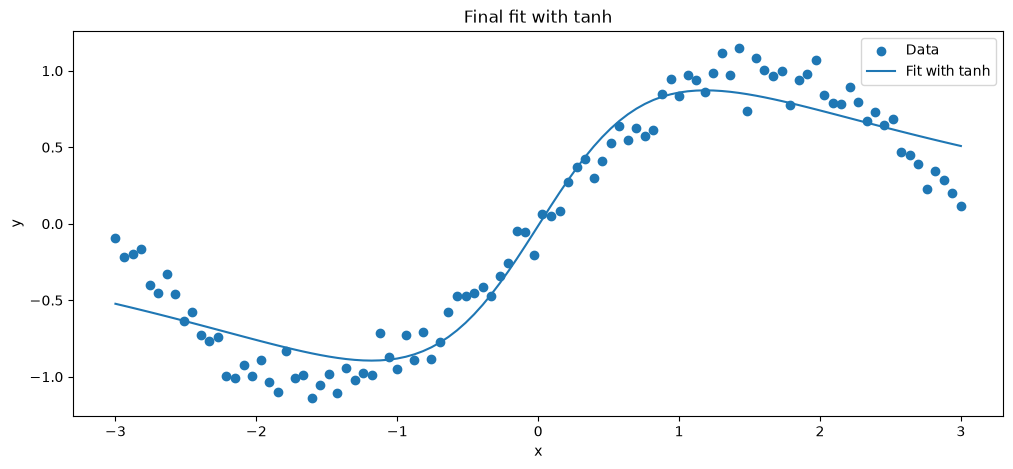

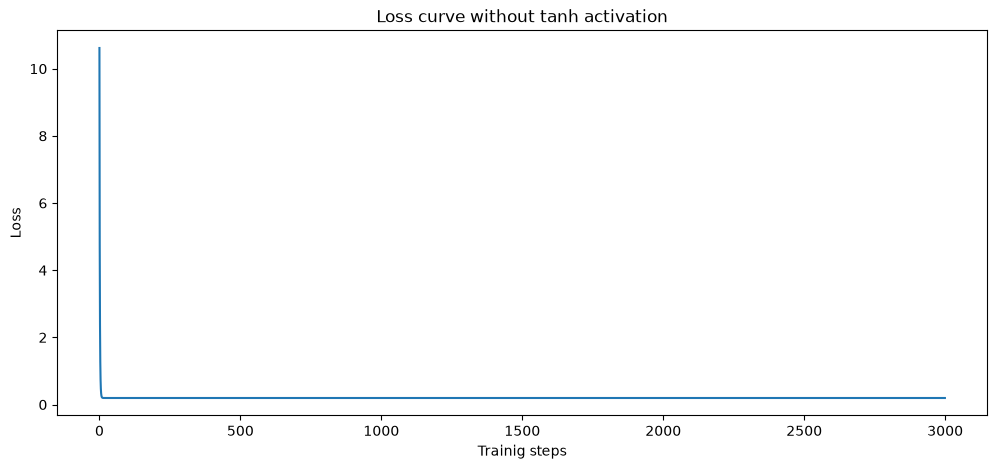

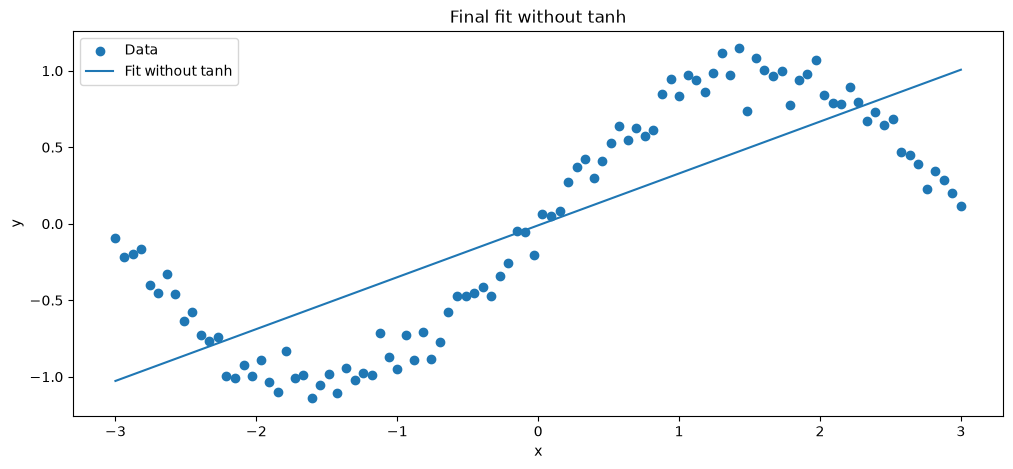

In [11]:
# Hidden layers and activations

# Reshaping x and y
x = x.reshape(-1,1)
y=y.reshape(-1,1)

# Initializing the weights and biases
W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros(1)

lr = 0.01
steps = 3000
losses = []

# Forward pass
z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2
loss = np.mean((y_hat - y)  ** 2)

# Backward pass
d_yhat = 2 * (y_hat -y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis = 0)
dh = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1
db1 = dz1.sum(axis = 0)

# Updating all parameters
for step in range(steps):
    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y)  ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat -y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis = 0)

    # Updating the parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

# Plotting the loss curve and final fit over the data
plt.figure(figsize=(12, 5))
plt.plot(losses)
plt.title("Loss curve with tanh activation")
plt.xlabel("Trainig steps")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, label="Fit with tanh")
plt.title("Final fit with tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Re-run without non linear activation
W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros(8)

W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros(1)

linear_losses = []

for step in range(3000):

    # Forward pass without tanh
    z1 = x @ W1_linear + b1_linear
    h = z1
    y_hat_linear = h @ W2_linear + b2_linear

    loss = np.mean((y_hat_linear - y) ** 2)
    linear_losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat_linear - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2_linear.T

    # No tanh, so derivative is 1
    dz1 = dh

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1_linear -= lr * dW1
    b1_linear -= lr * db1
    W2_linear -= lr * dW2
    b2_linear -= lr * db2

# Plotting the loss curve and final fit over the data
plt.figure(figsize=(12, 5))
plt.plot(linear_losses)
plt.title("Loss curve without tanh activation")
plt.xlabel("Trainig steps")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat_linear, label="Fit without tanh")
plt.title("Final fit without tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Observation: With the tanh activation function , the network was able to learn the no linear sine wave pattern and produced a curved fit which almost matched the data but when the tanh activation was removed, the network produced a straight line fit which did not match the data at all.This shows that non linear activation functions are important because without them multiple layers are equal to a single linear model.



